## Fig. 3b

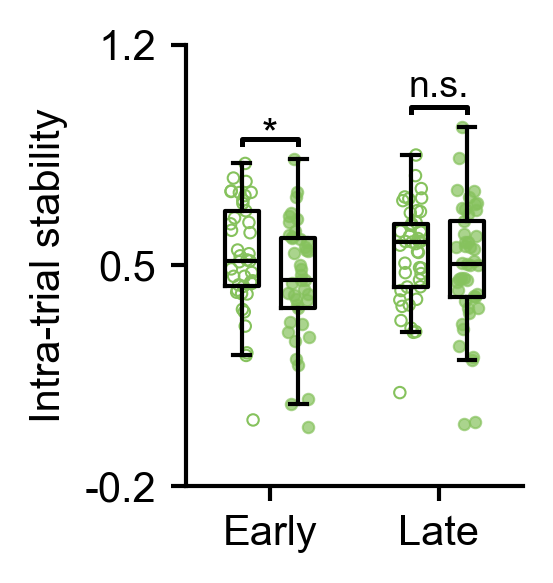

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../Results4Plots/PCVR.csv").copy()
df = df.copy()
df["CellType"] = df["CellType"].astype(str)
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

df = df[
    (df["CellType"].str.upper() == "PC")
    & (df["Stage"].isin(["early", "late"]))
    & (df["BoundaryCenter"].isin(["B", "C"]))
    & (df["Value"].notna())
].copy()

stage_levels = ["early", "late"]

colorPC = np.array([134, 194, 93]) / 255.0

xpos = {
    ("early", "B"): 1,
    ("early", "C"): 2,
    ("late", "B"): 4,
    ("late", "C"): 5
}

rng = np.random.default_rng(0)
jitter_width = 0.4

fig, ax = plt.subplots(figsize=(1.7, 1.8), dpi=300)

for st in stage_levels:
    for bc in ["B", "C"]:
        sub = df[(df["Stage"] == st) & (df["BoundaryCenter"] == bc)]
        y = sub["Value"].to_numpy(dtype=float)
        y = y[np.isfinite(y)]

        if y.size == 0:
            continue

        x0 = xpos[(st, bc)]
        jitter = (rng.random(y.size) - 0.5) * jitter_width

        if bc == "B":
            ax.scatter(x0 + jitter, y, s=7.5, marker="o", facecolors="none", edgecolors=colorPC, linewidths=0.5, alpha=1, zorder=1)
        else:
            ax.scatter(x0 + jitter, y, s=7.5, marker="o", facecolors=colorPC, edgecolors=colorPC, linewidths=0.5, alpha=0.7, zorder=1)

        bp = ax.boxplot(
            y,
            positions=[x0],
            widths=0.6,
            showfliers=False,
            patch_artist=False,
            boxprops=dict(color="k", linewidth=1),
            medianprops=dict(color="k", linewidth=1),
            whiskerprops=dict(color="k", linewidth=1),
            capprops=dict(color="k", linewidth=1)
        )

        for k in ["boxes", "medians", "whiskers", "caps"]:
            for artist in bp[k]:
                artist.set_zorder(10)

sig_label = {"early": "*", "late": "n.s."}

ymin, ymax = ax.get_ylim()
yr = ymax - ymin
h = 0.015 * yr
gap = 0.03 * yr
text_offset = 0.01 * yr

for st in stage_levels:
    x1 = xpos[(st, "B")]
    x2 = xpos[(st, "C")]

    yy = df.loc[df["Stage"] == st, "Value"].to_numpy(dtype=float)
    yy = yy[np.isfinite(yy)]

    if yy.size == 0:
        continue

    y = np.nanmax(yy) + 1.5 * gap

    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="k", zorder=10)

    if sig_label[st] == "*":
        y_text = y + h + text_offset - 0.02 * yr - 0.04
        fontsize_sig = 10
    else:
        y_text = y + h + text_offset
        fontsize_sig = 9

    ax.text((x1 + x2) / 2, y_text, sig_label[st], ha="center", va="bottom", fontname="Arial", fontsize=fontsize_sig, zorder=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for item in ax.get_yticklabels():
    item.set_fontname("Arial")

ax.set_ylabel("Intra-trial stability", fontsize=10, fontname="Arial")
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)

ax.set_ylim(-0.2, 1.2)
ax.set_xlim(0, 6)
ax.set_yticks([-0.2, 0.5, 1.2])
ax.set_yticklabels(["-0.2", "0.5", "1.2"], fontname="Arial", fontsize=10)

plt.tight_layout(pad=0.2)
plt.show()

## Fig. 3c

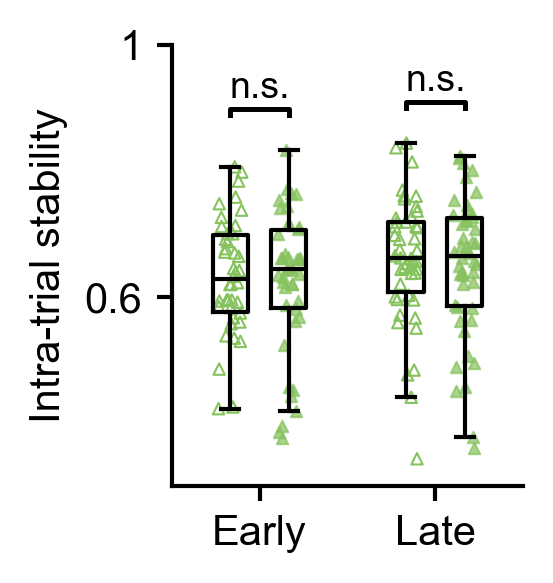

In [ ]:
df = pd.read_csv("../Results4Plots/PCR.csv").copy()
df = df.copy()
df["CellType"] = df["CellType"].astype(str)
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

df = df[
    (df["CellType"].str.upper() == "PC")
    & (df["Stage"].isin(["early", "late"]))
    & (df["BoundaryCenter"].isin(["B", "C"]))
    & (df["Value"].notna())
].copy()

stage_levels = ["early", "late"]

colorPC = np.array([134, 194, 93]) / 255.0

xpos = {
    ("early", "B"): 1,
    ("early", "C"): 2,
    ("late", "B"): 4,
    ("late", "C"): 5
}

rng = np.random.default_rng(0)
jitter_width = 0.4

fig, ax = plt.subplots(figsize=(1.7, 1.8), dpi=300)

for st in stage_levels:
    for bc in ["B", "C"]:
        sub = df[(df["Stage"] == st) & (df["BoundaryCenter"] == bc)]
        y = sub["Value"].to_numpy(dtype=float)
        y = y[np.isfinite(y)]

        if y.size == 0:
            continue

        x0 = xpos[(st, bc)]
        jitter = (rng.random(y.size) - 0.5) * jitter_width

        if bc == "B":
            ax.scatter(x0 + jitter, y, s=7.5, marker="^", facecolors="none", edgecolors=colorPC, linewidths=0.5, alpha=1, zorder=1)
        else:
            ax.scatter(x0 + jitter, y, s=7.5, marker="^", facecolors=colorPC, edgecolors=colorPC, linewidths=0.5, alpha=0.7, zorder=1)

        bp = ax.boxplot(
            y,
            positions=[x0],
            widths=0.6,
            showfliers=False,
            patch_artist=False,
            boxprops=dict(color="k", linewidth=1),
            medianprops=dict(color="k", linewidth=1),
            whiskerprops=dict(color="k", linewidth=1),
            capprops=dict(color="k", linewidth=1)
        )

        for k in ["boxes", "medians", "whiskers", "caps"]:
            for artist in bp[k]:
                artist.set_zorder(10)

ymin, ymax = ax.get_ylim()
yr = ymax - ymin
h = 0.015 * yr
gap = 0.03 * yr
text_offset = 0.01 * yr

for st in stage_levels:
    x1 = xpos[(st, "B")]
    x2 = xpos[(st, "C")]

    yy = df.loc[df["Stage"] == st, "Value"].to_numpy(dtype=float)
    yy = yy[np.isfinite(yy)]

    if yy.size == 0:
        continue

    y = np.nanmax(yy) + 3 * gap

    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="k", zorder=10)
    ax.text((x1 + x2) / 2, y + h + text_offset, "n.s.", ha="center", va="bottom", fontname="Arial", fontsize=9, zorder=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for item in ax.get_yticklabels():
    item.set_fontname("Arial")

ax.set_ylabel("Intra-trial stability", fontsize=10, fontname="Arial")
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)

ax.set_ylim(0.3, 1.0)
ax.set_xlim(0, 6)
ax.set_yticks([0.6, 1.0])
ax.set_yticklabels(["0.6", "1"], fontname="Arial", fontsize=10)

plt.tight_layout(pad=0.2)
plt.show()

## Fig. 3d

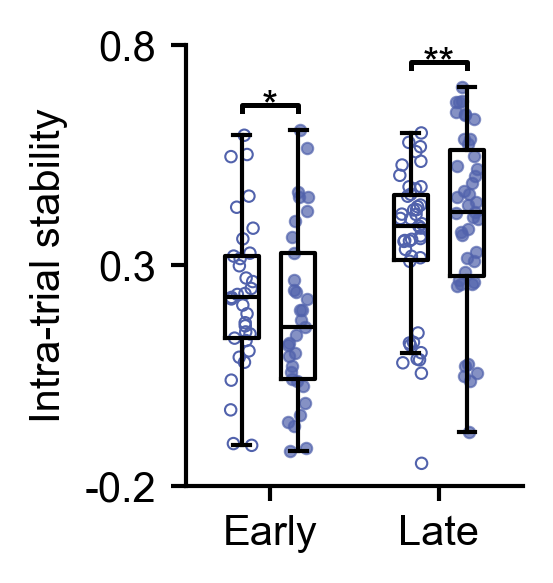

In [3]:
df = pd.read_csv("../Results4Plots/GCVR.csv").copy()
df = df.copy()
df["CellType"] = df["CellType"].astype(str)
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

df = df[
    (df["CellType"].str.upper() == "GC")
    & (df["Stage"].isin(["early", "late"]))
    & (df["BoundaryCenter"].isin(["B", "C"]))
    & (df["Value"].notna())
].copy()

stage_levels = ["early", "late"]

colorGC = np.array([81, 98, 172]) / 255.0

xpos = {
    ("early", "B"): 1,
    ("early", "C"): 2,
    ("late", "B"): 4,
    ("late", "C"): 5
}

rng = np.random.default_rng(0)
jitter_width = 0.4

fig, ax = plt.subplots(figsize=(1.7, 1.8), dpi=300)

for st in stage_levels:
    for bc in ["B", "C"]:
        sub = df[(df["Stage"] == st) & (df["BoundaryCenter"] == bc)]
        y = sub["Value"].to_numpy(dtype=float)
        y = y[np.isfinite(y)]

        if y.size == 0:
            continue

        x0 = xpos[(st, bc)]
        jitter = (rng.random(y.size) - 0.5) * jitter_width

        if bc == "B":
            ax.scatter(x0 + jitter, y, s=7.5, marker="o", facecolors="none", edgecolors=colorGC, linewidths=0.5, alpha=1, zorder=1)
        else:
            ax.scatter(x0 + jitter, y, s=7.5, marker="o", facecolors=colorGC, edgecolors=colorGC, linewidths=0.5, alpha=0.7, zorder=1)

        bp = ax.boxplot(
            y,
            positions=[x0],
            widths=0.6,
            showfliers=False,
            patch_artist=False,
            boxprops=dict(color="k", linewidth=1),
            medianprops=dict(color="k", linewidth=1),
            whiskerprops=dict(color="k", linewidth=1),
            capprops=dict(color="k", linewidth=1)
        )

        for k in ["boxes", "medians", "whiskers", "caps"]:
            for artist in bp[k]:
                artist.set_zorder(10)

sig_label = {"early": "*", "late": "**"}

ymin, ymax = ax.get_ylim()
yr = ymax - ymin
h = 0.015 * yr
gap = 0.03 * yr
text_offset = 0.01 * yr

for st in stage_levels:
    x1 = xpos[(st, "B")]
    x2 = xpos[(st, "C")]

    yy = df.loc[df["Stage"] == st, "Value"].to_numpy(dtype=float)
    yy = yy[np.isfinite(yy)]

    if yy.size == 0:
        continue

    y = np.nanmax(yy) + 1.5 * gap
    y_text = y + h + text_offset - 0.02 * yr - 0.04

    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="k", zorder=10)
    ax.text((x1 + x2) / 2, y_text, sig_label[st], ha="center", va="bottom", fontname="Arial", fontsize=10, zorder=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for item in ax.get_yticklabels():
    item.set_fontname("Arial")

ax.set_ylabel("Intra-trial stability", fontsize=10, fontname="Arial")
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)

ax.set_ylim(-0.2, 0.8)
ax.set_xlim(0, 6)
ax.set_yticks([-0.2, 0.3, 0.8])
ax.set_yticklabels(["-0.2", "0.3", "0.8"], fontname="Arial", fontsize=10)

plt.tight_layout(pad=0.2)
plt.show()

## Fig. 3e

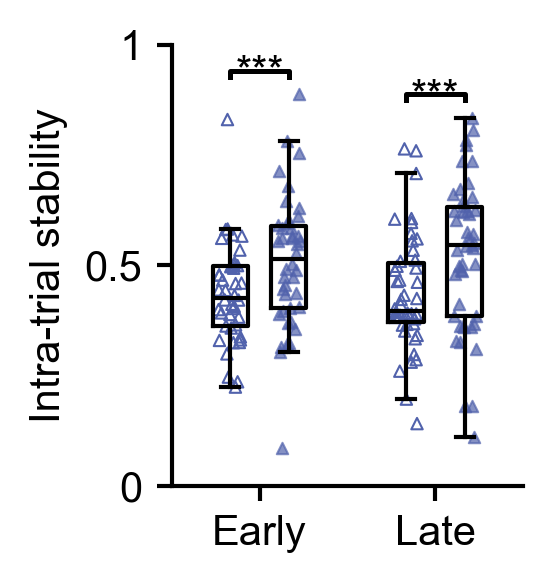

In [4]:
df = pd.read_csv("../Results4Plots/GCR.csv").copy()
df = df.copy()
df["CellType"] = df["CellType"].astype(str)
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

df = df[
    (df["CellType"].str.upper() == "GC")
    & (df["Stage"].isin(["early", "late"]))
    & (df["BoundaryCenter"].isin(["B", "C"]))
    & (df["Value"].notna())
].copy()

stage_levels = ["early", "late"]

colorGC = np.array([81, 98, 172]) / 255.0

xpos = {
    ("early", "B"): 1,
    ("early", "C"): 2,
    ("late", "B"): 4,
    ("late", "C"): 5
}

rng = np.random.default_rng(0)
jitter_width = 0.4

fig, ax = plt.subplots(figsize=(1.7, 1.8), dpi=300)

for st in stage_levels:
    for bc in ["B", "C"]:
        sub = df[(df["Stage"] == st) & (df["BoundaryCenter"] == bc)]
        y = sub["Value"].to_numpy(dtype=float)
        y = y[np.isfinite(y)]

        if y.size == 0:
            continue

        x0 = xpos[(st, bc)]
        jitter = (rng.random(y.size) - 0.5) * jitter_width

        if bc == "B":
            ax.scatter(x0 + jitter, y, s=7.5, marker="^", facecolors="none", edgecolors=colorGC, linewidths=0.5, alpha=1, zorder=1)
        else:
            ax.scatter(x0 + jitter, y, s=7.5, marker="^", facecolors=colorGC, edgecolors=colorGC, linewidths=0.5, alpha=0.7, zorder=1)

        bp = ax.boxplot(
            y,
            positions=[x0],
            widths=0.6,
            showfliers=False,
            patch_artist=False,
            boxprops=dict(color="k", linewidth=1),
            medianprops=dict(color="k", linewidth=1),
            whiskerprops=dict(color="k", linewidth=1),
            capprops=dict(color="k", linewidth=1)
        )

        for k in ["boxes", "medians", "whiskers", "caps"]:
            for artist in bp[k]:
                artist.set_zorder(10)

ymin, ymax = ax.get_ylim()
yr = ymax - ymin
h = 0.015 * yr
gap = 0.03 * yr
text_offset = 0.01 * yr

for st in stage_levels:
    x1 = xpos[(st, "B")]
    x2 = xpos[(st, "C")]

    yy = df.loc[df["Stage"] == st, "Value"].to_numpy(dtype=float)
    yy = yy[np.isfinite(yy)]

    if yy.size == 0:
        continue

    y = np.nanmax(yy) + 1.5 * gap
    y_text = y + h + text_offset - 0.02 * yr - 0.04

    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="k", zorder=10)
    ax.text((x1 + x2) / 2, y_text, "***", ha="center", va="bottom", fontname="Arial", fontsize=10, zorder=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for item in ax.get_yticklabels():
    item.set_fontname("Arial")

ax.set_ylabel("Intra-trial stability", fontsize=10, fontname="Arial")
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)

ax.set_ylim(0, 1)
ax.set_xlim(0, 6)
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(["0", "0.5", "1"], fontname="Arial", fontsize=10)

plt.tight_layout(pad=0.2)
plt.show()

## Fig. 3f

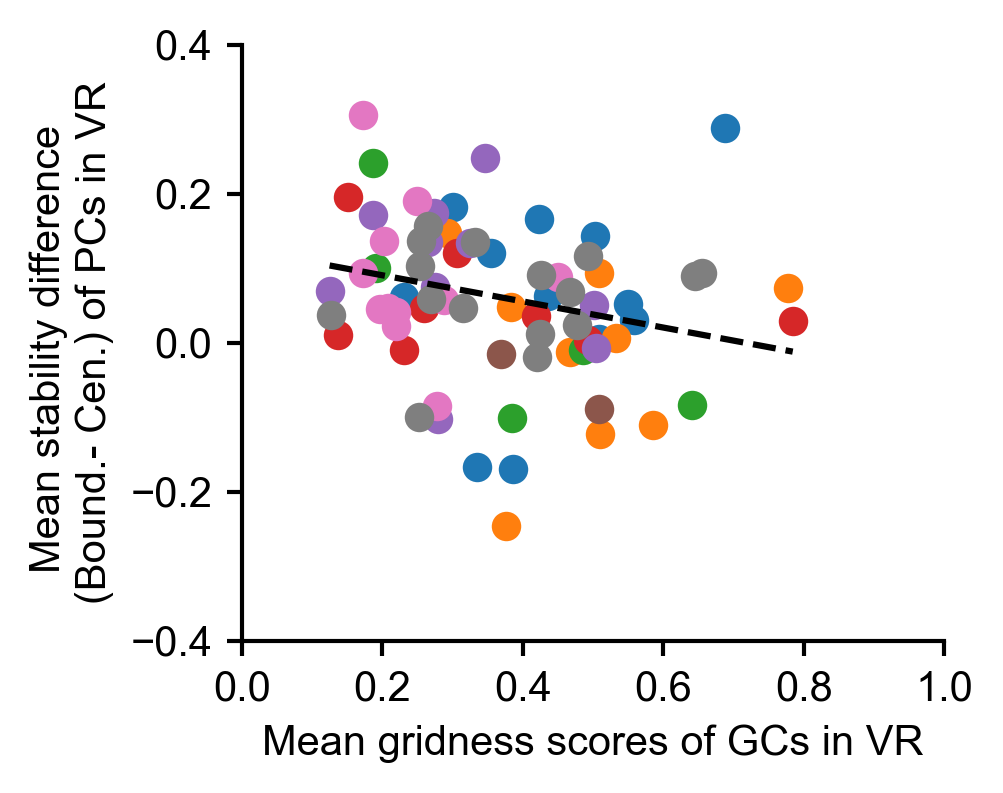

-0.24274376083917268
0.037170254771067404


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.stats import pearsonr

def _to_py(x):
    if isinstance(x, np.ndarray):
        if x.size == 0:
            return None
        if x.size == 1:
            return _to_py(x.item())
    return x

def get_field(obj, name, default=None):
    if obj is None:
        return default
    if isinstance(obj, np.void) and obj.dtype.names and name in obj.dtype.names:
        return _to_py(obj[name])
    if isinstance(obj, dict) and name in obj:
        return _to_py(obj[name])
    if hasattr(obj, name):
        return _to_py(getattr(obj, name))
    return default

mat = loadmat("../Results4Plots/PCGCVR.mat", squeeze_me=True, struct_as_record=False)
data_list = list(np.atleast_1d(mat["data"]))
n_animals = len(data_list)

fig, ax = plt.subplots(figsize=(3.2, 2.5), dpi=300)

cmap = plt.get_cmap("tab10")
colors = [cmap(i % 10) for i in range(n_animals)]

allGridness = []
allMeanDiff = []

for ia, animal in enumerate(data_list):
    xList = []
    yList = []

    trials = get_field(animal, "trial")

    if trials is None:
        continue

    for tr in np.atleast_1d(trials):
        x = get_field(tr, "meanGridness", np.nan)
        y = get_field(tr, "meanDiff", np.nan)

        try:
            x = float(np.asarray(x).squeeze())
            y = float(np.asarray(y).squeeze())
        except (TypeError, ValueError):
            continue

        if np.isfinite(x) and np.isfinite(y) and -2 < y < 2:
            xList.append(x)
            yList.append(y)
            allGridness.append(x)
            allMeanDiff.append(y)

    if xList:
        ax.scatter(xList, yList, s=50, marker="o", facecolors=colors[ia], edgecolors=colors[ia], linewidths=0, alpha=1)

allGridness = np.asarray(allGridness, dtype=float)
allMeanDiff = np.asarray(allMeanDiff, dtype=float)

r_value = np.nan
p_value = np.nan

if allGridness.size >= 2:
    p = np.polyfit(allGridness, allMeanDiff, 1)
    xfit = np.linspace(allGridness.min(), allGridness.max(), 100)
    ax.plot(xfit, np.polyval(p, xfit), "k--", linewidth=1.5)
    r_value, p_value = pearsonr(allGridness, allMeanDiff)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for item in ax.get_xticklabels() + ax.get_yticklabels():
    item.set_fontname("Arial")

ax.set_ylabel("Mean stability difference \n(Bound.- Cen.) of PCs in VR", fontsize=10, fontname="Arial")
ax.set_xlabel("Mean gridness scores of GCs in VR", fontsize=10, fontname="Arial")

ax.set_ylim(-0.4, 0.4)
ax.set_yticks(np.arange(-0.4, 0.401, 0.2))
ax.set_xlim(0, 1.0)
ax.set_xticks(np.arange(0, 1.001, 0.2))

plt.tight_layout(pad=0.2)
plt.show()

print(r_value)
print(p_value)

## Fig. 3g

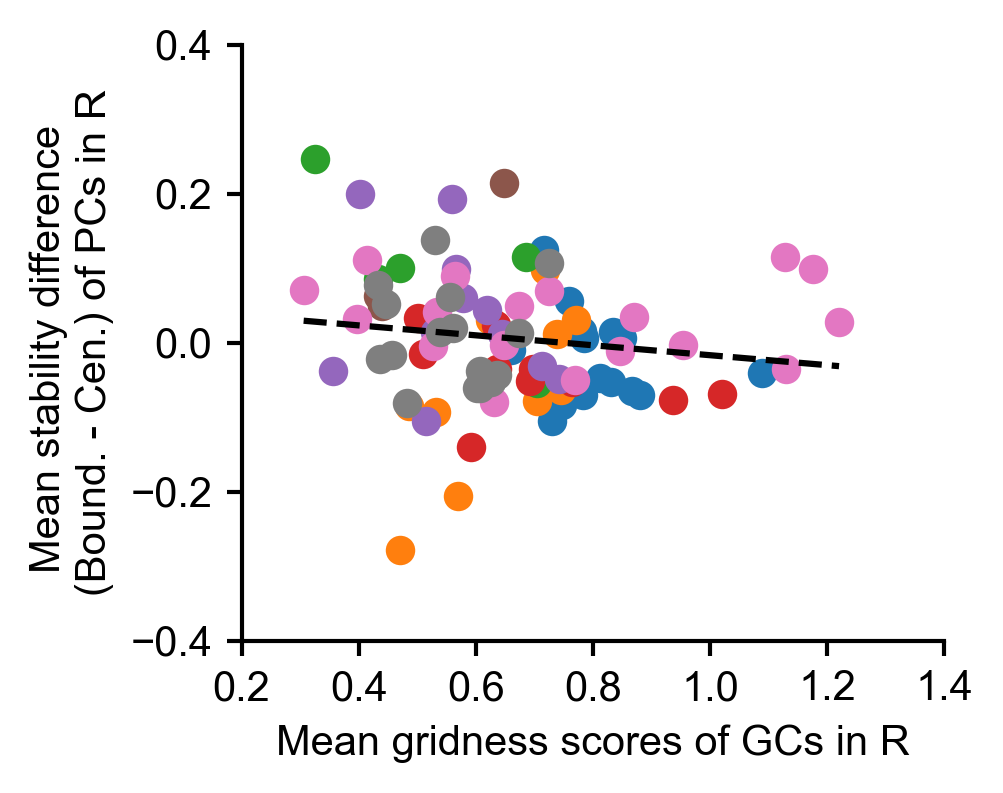

-0.14846008625539794
0.16745455761101402


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.stats import pearsonr

def _to_py(x):
    if isinstance(x, np.ndarray):
        if x.size == 0:
            return None
        if x.size == 1:
            return _to_py(x.item())
    return x

def get_field(obj, name, default=None):
    if obj is None:
        return default
    if isinstance(obj, np.void) and obj.dtype.names and name in obj.dtype.names:
        return _to_py(obj[name])
    if isinstance(obj, dict) and name in obj:
        return _to_py(obj[name])
    if hasattr(obj, name):
        return _to_py(getattr(obj, name))
    return default

mat = loadmat("../Results4Plots/PCGCR.mat", squeeze_me=True, struct_as_record=False)
data_list = list(np.atleast_1d(mat["data"]))
n_animals = len(data_list)

fig, ax = plt.subplots(figsize=(3.2, 2.5), dpi=300)

cmap = plt.get_cmap("tab10")
colors = [cmap(i % 10) for i in range(n_animals)]

allGridness = []
allMeanDiff = []

for ia, animal in enumerate(data_list):
    xList = []
    yList = []

    trials = get_field(animal, "trial")

    if trials is None:
        continue

    for tr in np.atleast_1d(trials):
        x = get_field(tr, "meanGridness", np.nan)
        y = get_field(tr, "meanDiff", np.nan)

        try:
            x = float(np.asarray(x).squeeze())
            y = float(np.asarray(y).squeeze())
        except (TypeError, ValueError):
            continue

        if np.isfinite(x) and np.isfinite(y) and -2 < y < 2:
            xList.append(x)
            yList.append(y)
            allGridness.append(x)
            allMeanDiff.append(y)

    if xList:
        ax.scatter(xList, yList, s=50, marker="o", facecolors=colors[ia], edgecolors=colors[ia], linewidths=0, alpha=1)

allGridness = np.asarray(allGridness, dtype=float)
allMeanDiff = np.asarray(allMeanDiff, dtype=float)

r_value = np.nan
p_value = np.nan

if allGridness.size >= 2:
    p = np.polyfit(allGridness, allMeanDiff, 1)
    xfit = np.linspace(allGridness.min(), allGridness.max(), 100)
    ax.plot(xfit, np.polyval(p, xfit), "k--", linewidth=1.5)

    r_value, p_value = pearsonr(allGridness, allMeanDiff)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for item in ax.get_xticklabels() + ax.get_yticklabels():
    item.set_fontname("Arial")

ax.set_ylabel("Mean stability difference \n(Bound. - Cen.) of PCs in R", fontsize=10, fontname="Arial")
ax.set_xlabel("Mean gridness scores of GCs in R", fontsize=10, fontname="Arial")

ax.set_ylim(-0.4, 0.4)
ax.set_yticks(np.arange(-0.4, 0.401, 0.2))
ax.set_xlim(0.2, 1.4)
ax.set_xticks(np.arange(0.2, 1.401, 0.2))

plt.tight_layout(pad=0.2)
plt.show()

print(r_value)
print(p_value)